<a href="https://colab.research.google.com/github/burningdust/ESAA/blob/main/YB_Session/ESAA_YB_0522_%EC%97%B0%EC%8A%B5%EB%AC%B8%EC%A0%9C_%EC%B0%A8%EC%9B%90%EC%B6%95%EC%86%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 데이터 로드
from sklearn.datasets import fetch_openml
mnist=fetch_openml('mnist_784', version=1)

In [2]:
# train, test split
X_train = mnist['data'][:60000]
y_train = mnist['target'][:60000]
X_test = mnist['data'][60000:]
y_test = mnist['target'][60000:]

* 랜덤포레스트에 적용

In [3]:
# 랜덤포레스트에 적용 (n_estimators=10, random_state=42)

from sklearn.ensemble import RandomForestClassifier
rnd_clf = RandomForestClassifier(n_estimators=10, random_state=42)
rnd_clf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

In [4]:
# 정확도 결과
from sklearn.metrics import accuracy_score
y_pred = rnd_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.9492

# 1. PCA

* PCA로 변환한 데이터 세트에 랜덤 포레스트 적용

In [5]:
# PCA 라이브러리 불러오기
from sklearn.decomposition import PCA

In [6]:
# PCA 적용 95% : n_components=0.95
pca = PCA(n_components=0.95)
X_train_reduced = pca.fit_transform(X_train)

In [7]:
# PCA 이후 랜덤포레스트 훈련
rnd_clf2 = RandomForestClassifier(n_estimators=10, random_state=42)
rnd_clf2.fit(X_train_reduced, y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

In [8]:
# 정확도 결과 (X_test도 PCA 적용해야합니다.)
x_test_reduced = pca.transform(X_test)
y_pred = rnd_clf2.predict(x_test_reduced)
accuracy_score(y_test, y_pred)

0.8925

**관련 문제**

* PCA모델을 와인 데이터셋에 적용하여 차원을 축소하고 그 결과를 그래프로 나타내보세요.

(1) 필요한 모듈 불러오기

In [9]:
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

(2)  load_wine을 사용해 데이터셋을 생성한다.

In [24]:
wine = load_wine()
wine_df = pd.DataFrame(wine.data, columns=wine.feature_names)
wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


(3) X에 표준 스케일링(Standard scaling)을 적용하여 X_scaled을 생성한다.

In [25]:
X = wine_df.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

(4) PCA 모델을 X에 적용하여 2개의 차원으로 추출한다. 단, random_state=1234로 설정한다.

In [26]:
#PCA 모델을 X_scaled에 적용하여 2개의 차원으로 추출한다.

pca2 = PCA(n_components=2, random_state=1234)
pca2.fit(X_scaled)

PCA(n_components=2, random_state=1234)

(5) 추출한 피처를 그래프로 나타내라.

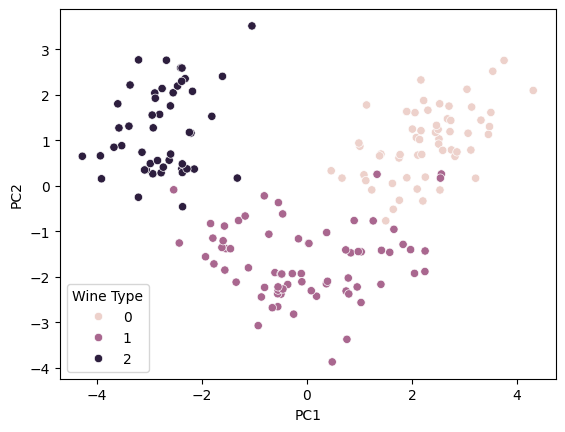

In [32]:
X_extracted = pca2.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_extracted, columns=['component_1', 'component_2'])
pca_df['target'] = wine.target

sns.scatterplot(x='component_1', y='component_2', hue='target', data=pca_df)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Wine Type')
plt.show()

# 2. LDA

- LDA로 변환한 데이터 세트에 랜덤 포레스트 적용

In [18]:
# LDA 라이브러리 불러오기
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [21]:
# LDA 적용 : n_components=5
lda = LinearDiscriminantAnalysis(n_components=5)
X_train_lda = lda.fit_transform(X_train, y_train)

In [22]:
# LDA 이후 랜덤포레스트 훈련
rnd_clf_lda = RandomForestClassifier(n_estimators=10, random_state=42)
rnd_clf_lda.fit(X_train_lda, y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

In [23]:
# 정확도 결과 (X_test도 LDA 적용해야합니다.)
from sklearn.metrics import accuracy_score
X_test_lda = lda.transform(X_test)
y_pred = rnd_clf_lda.predict(X_test_lda)
accuracy_score(y_test, y_pred)

0.8301